# Signature-Based Image Distance — Method B Phase 1: Stream Construction

## Motivation

Every Lipschitz estimate in this project's Experiment 2 (`mnist_lipschitz`) reduces to the
same ratio, `|margin_i - margin_j| / distance(x_i, x_j)` — and every denominator tried so
far has been a distance over the *raw pixel grid* (Euclidean, ridge-regularized Mahalanobis,
or a UMAP embedding — see `mnist_lipschitz/README.md`). We now try to build the denominator from **path signatures** of low-dimensional
*streams* extracted from the image, instead of a distance over pixels directly.

We first build and visually sanity-check streams for two independent, fixed,
non-learned methods — no signature computation, no distance metric, no adversarial
evaluation yet. 

**This notebook covers Method B only** (reference-line stream).

- **Method B — reference-line stream**: 8 horizontal + 8 vertical fixed lines through the
  image, each sampled at 32 points via bilinear interpolation. Stream: `(16, 32, 2)`, columns
  `[t, intensity]` per line.

The line geometry is fixed and shared across every image (no dependence on a trained
classifier's own features), so the resulting streams are directly comparable across images —
the property the rest of the pipeline (Phase 2 onward) depends on.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

%load_ext autoreload
%autoreload 2

%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import display

from signature_distance import run_experiment

## Build Method B streams for one sample image per digit

`stream_construction_demo` (in `run_experiment.py`) loads the fixed 1000-image eval pool
(`data_pool.load_eval_pool`), builds the 16 reference lines once (shared across every
image, per the design), and constructs the stream for one sample image per digit — saving an
overlay + stream plot per digit to `results/` along the way.

pool: torch.Size([1000, 28, 28]) torch.Size([1000])
lines: torch.Size([16, 32, 2])


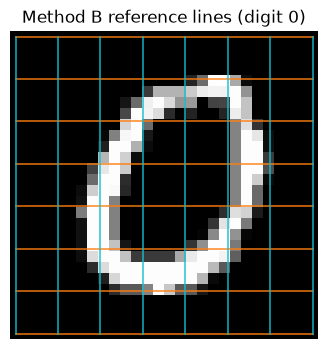

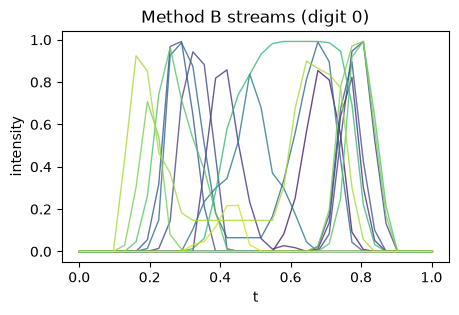

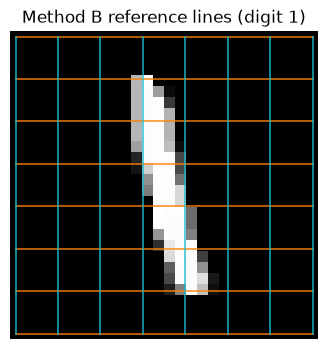

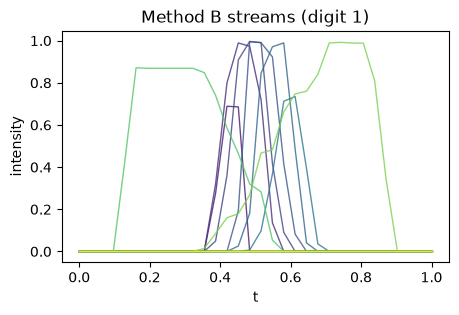

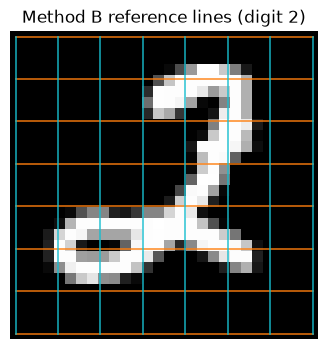

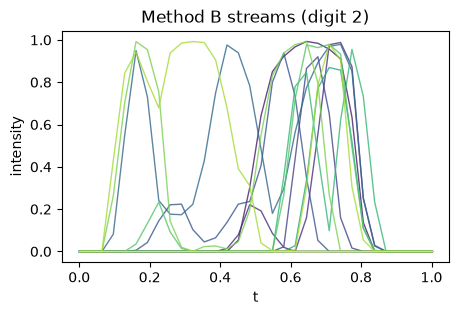

In [2]:
result = run_experiment.stream_construction_demo(n_digits=3)
print('pool:', result['images'].shape, result['labels'].shape)
print('lines:', result['lines'].shape)

## Reference-line overlay + stream, per digit

Each panel: the 8 horizontal (orange) + 8 vertical (cyan) reference lines overlaid on the
image, and the resulting per-line intensity vs. `t` streams (one curve per line, colored by
line index). Sanity check: lines crossing the digit's stroke should show a visible intensity
bump partway along `t`; lines missing the stroke entirely should stay near zero.

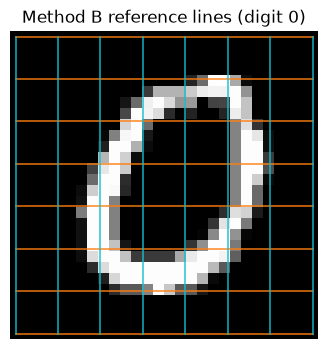

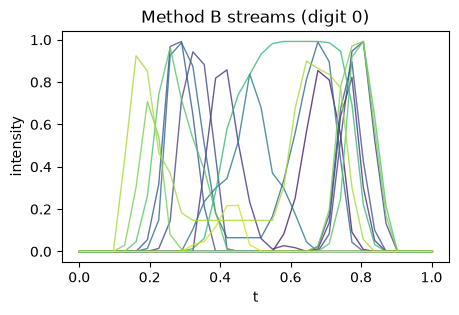

In [3]:
display(result['figures']['digit0_overlay'])
display(result['figures']['digit0_stream'])

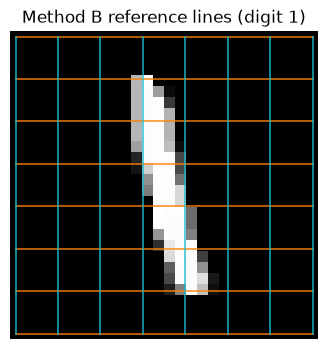

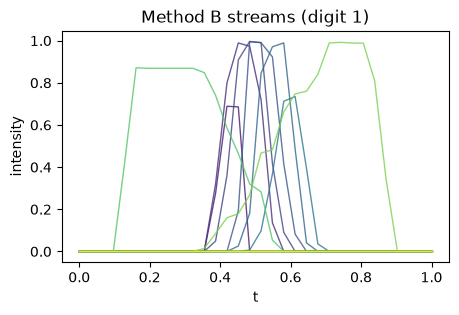

In [4]:
display(result['figures']['digit1_overlay'])
display(result['figures']['digit1_stream'])

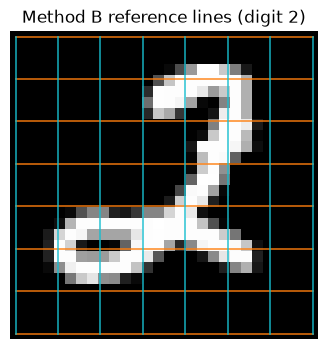

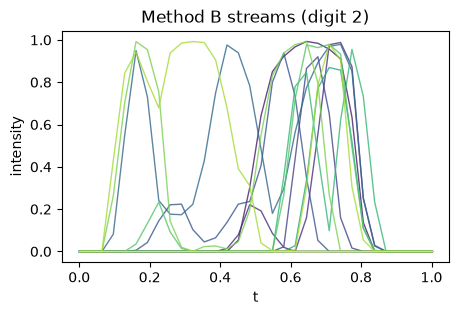

In [5]:
display(result['figures']['digit2_overlay'])
display(result['figures']['digit2_stream'])

## Status

Method B produces visually sane streams for every digit shown above: reference lines span
the full image and their intensity streams show clear bumps where a line crosses the digit.
Phase 1 stops here per `PLAN.md`'s scope boundary: no signature computation, no distance
metric, no `roughpy-jax` import. Next: Phase 2 (truncated signatures), not started.